# Gaussian Sampling on an Infinite Domain

In [2]:
import numpy as np

In [3]:
import os
import os
import sys
from datetime import datetime
from pathlib import Path
from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)

notebook_dir = Path.cwd().resolve()
repo_root = next(
    (path for path in [notebook_dir, *notebook_dir.parents] if (path / "utils").is_dir()),
    notebook_dir,
)    
import plotting
import pinns_infinite
import infinite
reload(plotting)
reload(pinns_infinite)
reload(infinite)
import numpy as np
import sympy as sp
import pickle
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
from pinns_infinite import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf,build_models_KAN
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)
from plotting import plot_histories_comparison

set_seed(42)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

/home/orincon/miniconda3/envs/PIKAN-unbounded-domains-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Generate Gaussian observations and evaluation data

In [4]:
(
    X_obs,
    U_obs,
    X_obs_k,
    K_obs,
    X_pde,
    F_pde,
    X,
    Y,
    U,
    K,
) = generate_dataset_inf(
    sigma=5.5,
    eval_domain=(-10.0, 10.0, -10.0, 10.0),
    sampling="gaussian",
    n_obs_u=100,
    n_obs_k=100,
    n_pde=1000,
    plot=False,
    device=device,
    seed=42,
)

## 3. Load the trained KAN models

In [5]:
checkpoint_path = os.path.join(
    "..", "03_individual_prediction", "results", "pikan_infinite_gaussian_weights.pt"
)
checkpoint = torch.load(checkpoint_path, map_location=device)
saved_config = checkpoint["config"]

model_u, model_k = build_models_KAN(
    device,
    hidden_layers=saved_config["hidden_layers"],
    hidden_units=saved_config["hidden_units"],
    grid_size=saved_config["grid_size"],
    spline_order=saved_config["spline_order"],
)

model_u.load_state_dict(checkpoint["model_u"])
model_k.load_state_dict(checkpoint["model_k"])
model_u.eval()
model_k.eval()

print(f"Loaded model from: {checkpoint_path}")
print(f"Stored mean global error: {checkpoint['metrics']['err_mean_global']:.6e}")


Loaded model from: ../03_individual_prediction/results/pikan_infinite_gaussian_weights.pt
Stored mean global error: 1.748967e-03


## 4. Evaluate spatial generalization and create the figure


Spatial generalization (MAE)
Training domain : [-5, 5] × [-5, 5]
Evaluation domain : [-10, 10] × [-10, 10]

Global MAE
u : 2.420e-03
k : 1.078e-03

Inside training domain
u : 2.586e-03
k : 7.106e-04

Outside training domain
u : 2.365e-03
k : 1.200e-03
Maximum |u_hat - u|: 0.021525
Maximum |k_hat - k|: 0.010665
Prediction plot saved to: figures/gaussian_infinite.pdf


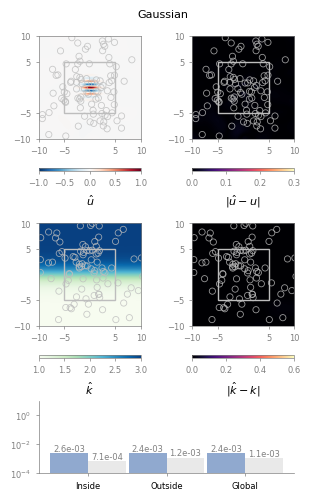

In [6]:
results = evaluate_model_inf(
    model_u=model_u,
    model_k=model_k,

    analytical_solution=analytical_solution_inf,
    coefficient=coefficient_inf,

    X_obs=X_obs,
    X_obs_k=X_obs_k,

    sampling="Gaussian",

    # Training domain
    train_xmin=-5,
    train_xmax=5,
    train_ymin=-5,
    train_ymax=5,

    # Larger domain used ONLY for evaluation
    eval_xmin=-10,
    eval_xmax=10,
    eval_ymin=-10,
    eval_ymax=10,

    n_grid=400,

    alpha=0.5,
    beta=5.0,
    epsilon=1.0,

    device=device,

    plot=True,
    verbose=True,

    save_results=False,
    results_dir="results",

    save_plot=True,
    plot_path="figures/gaussian_infinite.pdf",

    # Manually cap the error colorbars (set to None to use the defaults)
    err_u_max=0.3,
    err_k_max=0.6,

    # Decimal places shown on the error colorbar tick labels
    err_u_decimals=1,
    err_k_decimals=1,
)

## Quantify the improvement over uniform sampling

In [7]:
# Evaluate the uniform-sampling checkpoint with the same protocol for a direct comparison
uniform_weights_path = repo_root / "main" / "03_individual_prediction" / "results" / "pikan_infinite_uniform_weights.pt"
uniform_checkpoint = torch.load(uniform_weights_path, map_location=device)
uniform_saved_config = uniform_checkpoint["config"]

# Architecture must match the checkpoint's own config, not the Gaussian model's config
model_u_uniform, model_k_uniform = build_models_KAN(
    device=device,
    hidden_layers=uniform_saved_config["hidden_layers"],
    hidden_units=uniform_saved_config["hidden_units"],
    grid_size=uniform_saved_config["grid_size"],
    spline_order=uniform_saved_config["spline_order"],
)
model_u_uniform.load_state_dict(uniform_checkpoint["model_u"])
model_k_uniform.load_state_dict(uniform_checkpoint["model_k"])
model_u_uniform.eval()
model_k_uniform.eval()

(X_obs_uniform, _, X_obs_k_uniform, *_rest) = generate_dataset_inf(
    alpha=0.5,
    beta=5.0,
    epsilon=1.0,
    train_domain=(-5.0, 5.0, -5.0, 5.0),
    eval_domain=(-10.0, 10.0, -10.0, 10.0),
    sampling="uniform",
    n_obs_u=100,
    n_obs_k=100,
    n_pde=1000,
    plot=False,
    device=device,
    seed=42,
)

results_uniform = evaluate_model_inf(
    model_u=model_u_uniform,
    model_k=model_k_uniform,
    analytical_solution=analytical_solution_inf,
    coefficient=coefficient_inf,
    X_obs=X_obs_uniform,
    X_obs_k=X_obs_k_uniform,
    sampling="uniform",
    train_xmin=-5, train_xmax=5, train_ymin=-5, train_ymax=5,
    eval_xmin=-10, eval_xmax=10, eval_ymin=-10, eval_ymax=10,
    n_grid=400,
    alpha=0.5,
    beta=5.0,
    epsilon=1.0,
    device=device,
    plot=False,
    verbose=False,
    save_results=False,
)

# Improvement factor = orders of magnitude by which the uniform-sampling error exceeds the exponential-sampling error
regions = ["inside", "outside", "global"]
lines = ["Exponential vs. uniform sampling: improvement (orders of magnitude, log10(uniform error / exponential error))"]
for region in regions:
    ratio_u = results_uniform[f"err_u_{region}"] / results[f"err_u_{region}"]
    ratio_k = results_uniform[f"err_k_{region}"] / results[f"err_k_{region}"]
    log_u = np.log10(ratio_u)
    log_k = np.log10(ratio_k)
    combined = (log_u + log_k) / 2
    lines.append(f"{region:8s}: u {log_u:+6.2f} | k {log_k:+6.2f} | combined {combined:+6.2f}")

summary = "\n".join(lines)
print(summary)

output_path = repo_root / "main" / "04_sampling_approximation" / "data" / "exponential_vs_uniform_improvement_infinite.txt"
output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_text(summary + "\n")
print(f"\nImprovement summary saved to: {output_path}")

Exponential vs. uniform sampling: improvement (orders of magnitude, log10(uniform error / exponential error))
inside  : u  -0.01 | k  -0.09 | combined  -0.05
outside : u  +1.00 | k  +1.86 | combined  +1.43
global  : u  +0.88 | k  +1.78 | combined  +1.33

Improvement summary saved to: /home/orincon/unbounded-domains/main/04_sampling_approximation/data/exponential_vs_uniform_improvement_infinite.txt
